### Import necessary libraries

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import math

import tensorflow as tf
from tensorflow.keras.layers import ( 
    Input, Conv1D, Concatenate, BatchNormalization, ReLU, 
    Add, GlobalAveragePooling1D, Dense, Dropout, MultiHeadAttention, LayerNormalization) 
from tensorflow.keras.models import Model, load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import KLDivergence
from tensorflow.keras.optimizers import Adam

import datetime
from helper_functions import read_composition

from CNN import build_CNN
from Load_data import load_real_data, load_synthetic_data, load_bootstrapped_data, load_real_data_6_element_phantom
from metrics import mae_O, mae_C, mae_N, median_ae_O, median_ae_C, median_ae_N, mae_H, mae_Ca, mae_P
from loss import make_weighted_loss, make_compositional_and_density_loss


I0000 00:00:1778138722.900695   10433 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load real data

In [2]:
data_path_100mill = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_6_element_phantom/simulations_6_element_phantom/"

X_array,X_array_nøy, y_array = load_real_data_6_element_phantom(data_path = data_path_100mill, X_length=350, include_neutron_data=True, X_length_nøy=350)#, w_gradient=True)

X_array = np.stack((X_array, X_array_nøy), axis = 2)

#y_array = y_array[:,:6] # Do not include density for now

print("X_array shape:", X_array.shape)
print("X_array nøy shape:", X_array_nøy.shape)
print("y_array shape:", y_array.shape)

X_array shape: (545, 350, 2)
X_array nøy shape: (545, 350)
y_array shape: (545, 7)


ValueError: label must be scalar or have the same length as the input data, but found 7 for 2 datasets.

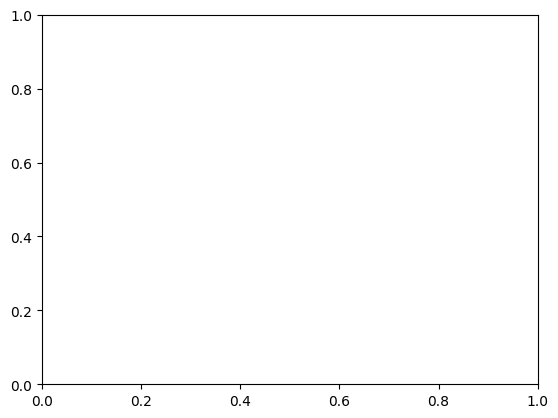

In [4]:
energy = np.linspace(0,7,350)
plt.figure()
plt.plot(energy, X_array[0], label = y_array[0])
plt.plot(energy, X_array[1], label = y_array[1])
plt.plot(energy, X_array[2], label = y_array[2])
plt.legend()
plt.show()

energy = np.linspace(0,150,499) #riktig?
plt.figure()
plt.plot(energy, X_array_nøy[0], label = y_array[0])
plt.plot(energy, X_array_nøy[1], label = y_array[1])
plt.plot(energy, X_array_nøy[2], label = y_array[2])
plt.legend()
plt.show()

### Training scheme 1

In [3]:
X_train, X_val_test, y_train, y_val_test = train_test_split(X_array, y_array, test_size = 0.20, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test,y_val_test, test_size = 0.5, random_state = 42)


X_val = np.concatenate((X_val, X_test[:10]), axis = 0)

y_val = np.concatenate((y_val, y_test[:10]), axis = 0)
X_test = X_test[10:]

y_test = y_test[10:]
print("Dataset 1: ")
print("X_train_1 (shape): ", X_train.shape)
print("X_val (shape): ", X_val.shape)
print("X_test (shape): ", X_test.shape)

print(y_val.shape)
print(y_test.shape)


Dataset 1: 
X_train_1 (shape):  (436, 350, 2)
X_val (shape):  (64, 350, 2)
X_test (shape):  (45, 350, 2)
(64, 7)
(45, 7)


### Plot validation data

[0.1058 0.2681 0.0807 0.1519 0.206  0.1875 1.694 ]
Minimum content of oxygen: 0.0074
Minimum content of carbon: 0.0027
Minimum content of nitrogen: 0.0043


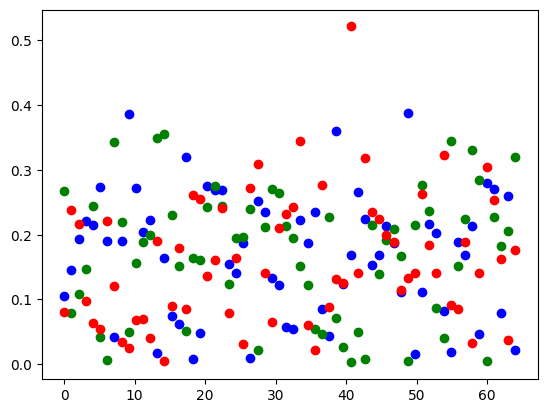

In [11]:
print(y_val[0])

O_mengde = []
C_mengde = []
N_mengde = []
H_mengde = []
Ca_mengde = []
P_mengde = []

for i in range(len(y_val)):
    O_mengde.append(y_val[i][0])
    C_mengde.append(y_val[i][1])
    N_mengde.append(y_val[i][2])
    H_mengde.append(y_val[i][3])
    Ca_mengde.append(y_val[i][4])
    P_mengde.append(y_val[i][5])

datapoints = np.linspace(0, len(y_val), len(y_val))

print("Minimum content of oxygen:", min(O_mengde))
print("Minimum content of carbon:", min(C_mengde))
print("Minimum content of nitrogen:", min(N_mengde))


plt.figure()
plt.scatter(datapoints, O_mengde, color = "blue", label = "oxygen")
plt.scatter(datapoints, C_mengde, color = "green", label = "carbon")
plt.scatter(datapoints, N_mengde, color = "red", label = "nitrogen")
plt.show()


### Training - scheme 1

In [ ]:
#model, attention_model = build_CNN(with_attention=True, num_channels=1,num_filters_1=64, num_filters_2=128) # added one channel for gradient # can now specify the number of filters here
model, attention_model = build_CNN(with_attention=True, num_channels=2, output_dim=6, auxillary_output = True, add_spes=True) 
# Monitoring via Tensorboard
modelname = "6_element_phantom_v06_multiple_inputs_1m5_specialization_32_nodes_kl_divergence_"
num_epochs = 15000
bs = 8
learning_rate = 1e-5 #prøv 1e-5 etterpå

loss_weighted = make_weighted_loss(w_O = 0.5, w_C=3.0, w_N = 0.5,w_H = 0.5, w_Ca = 0.5, w_P = 0.5)
#loss_pretrain = make_compositional_and_density_loss(lambda_comp=0.5, lambda_density=0.5)
#"kl_divergence"
#make_weighted_loss(w_O = 3.0, w_C=0.5, w_N = 0.5) #"kl_divergence"

# Define model name 
model_name_pretrain = f"bs{bs}_lr_{learning_rate:.6f}" + "_" + modelname

log_dir = "logs/fit/6_element_phantom_wo_density/" + model_name_pretrain + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callbacks = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq="epoch"
)

#model.compile(optimizer = Adam(learning_rate=learning_rate), loss = loss_pretrain, metrics = ["mae", mae_O,mae_C,mae_N,mae_H,mae_Ca,mae_P])

model.compile(optimizer = Adam(learning_rate=learning_rate), loss = {"composition": "kl_divergence","auxillary_output": "mae"}, loss_weights = {"composition": 3.0, "auxillary_output": 0.5}, metrics = {"composition" : ["mae", mae_O,mae_C,mae_N,mae_H,mae_Ca,mae_P], "auxillary_output": ["mae"]})

early_stopping = EarlyStopping(
    monitor="loss",
    mode = 'min',
    patience=15,
    restore_best_weights=True
)
'''callbacks=[tensorboard_callbacks, ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae.keras',
    monitor = "val_composition_mae",
    mode = "min",
    save_best_only=True)]'''

callbacks=[tensorboard_callbacks, ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae.keras',
    monitor = "val_composition_mae",
    mode = "min",
    save_best_only=True), ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_O.keras',
    monitor = "val_composition_mae_o",
    mode = "min",
    save_best_only=True),ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_c.keras',
    monitor = "val_composition_mae_c",
    mode = "min",
    save_best_only=True),ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_N.keras',
    monitor = "val_composition_mae_n",
    mode = "min",
    save_best_only=True),ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_H.keras',
    monitor = "val_composition_mae_h",
    mode = "min",
    save_best_only=True),ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_Ca.keras',
    monitor = "val_composition_mae__ca",
    mode = "min",
    save_best_only=True),ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_P.keras',
    monitor = "val_composition_mae_p",
    mode = "min",
    save_best_only=True), ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_auxillary_output.keras',
    monitor = "val_auxillary_output_mae",
    mode = "min",
    save_best_only=True)]


#callbacks=[tensorboard_callbacks, ModelCheckpoint(
#    f'models_6_element_phantom/wo_density/val_mae{{val_mae:.4f}}_val_mae_O_{{val_mae_o:.4f}}_val_mae_C_{{val_mae_c:.4f}}_val_mae_N_{{val_mae_n:.4f}}_val_mae_H_{{val_mae_h:.4f}}_val_mae_Ca_{{val_mae__ca:.4f}}_val_mae_P_{{val_mae_p:.4f}}_bs{bs}__lr{learning_rate:.4f}_epoch_{{epoch}}_'+modelname+'.keras',
#    save_best_only=True),
#    monitor = ]

# Ta med early stopping, eller?
#callbacks=[tensorboard_callbacks, ModelCheckpoint(
 #   f'models/new_more_data_attn_fixed/spect_bs{bs}__lr{learning_rate:.4f}_epoch_{{epoch}}_val_mae{{val_mae:.4f}}_val_mae_O_{{val_mae_o:.4f}}_val_mae_C_{{val_mae_c:.4f}}_val_mae_N_{{val_mae_n:.4f}}.keras',save_best_only=False)]

#callbacks=[tensorboard_callbacks, ModelCheckpoint(
 #   f'models/oxygen_aux/val_mae_{{val_mae:.4f}}_bs{bs}__lr{learning_rate:.5f}_epoch_{{epoch}}_val_mae_O_{{val_mae_o:.4f}}_val_mae_C_{{val_mae_c:.4f}}_val_mae_N_{{val_mae_n:.4f}}_val_median_ae_O_{{val_median_ae_o:.4f}}_val_median_ae_C_{{val_median_ae_c:.4f}}_val_median_ae_N_{{val_median_ae_n:.4f}}_oxygen_spesific.keras',save_best_only=False)]
#callbacks=[tensorboard_callbacks, ModelCheckpoint(
 #   f'models/oxygen_aux/aux_output_mae_val_{{val_auxillary_output_mae:.4f}}_epoch_{{epoch}}.keras',save_best_only=False)]


#history = model.fit([X_train,proton_counts_train], y_train, epochs = num_epochs,batch_size = bs,validation_data=([X_val, proton_counts_val],y_val),callbacks=callbacks)

#history = model.fit(X_train, y_train, epochs = num_epochs,batch_size = bs,validation_data=(X_val,y_val),callbacks=callbacks)


# Test for oxygen
history = model.fit(X_train, y = {"composition": y_train[:,:6], "auxillary_output": y_train[:,6]}, epochs = num_epochs,batch_size = bs,validation_data=(X_val,{"composition": y_val[:,:6], "auxillary_output": y_val[:,6]}),callbacks=callbacks, verbose = 0)


W0000 00:00:1778097651.416007 3647807 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/15000
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - auxillary_output_loss: 0.2599 - auxillary_output_mae: 0.2600 - composition_loss: 0.3858 - composition_mae: 0.1067 - composition_mae__ca: 0.1214 - composition_mae_c: 0.0857 - composition_mae_h: 0.1161 - composition_mae_n: 0.0976 - composition_mae_o: 0.0797 - composition_mae_p: 0.1378 - loss: 1.2937 - val_auxillary_output_loss: 0.2314 - val_auxillary_output_mae: 0.2314 - val_composition_loss: 0.3890 - val_composition_mae: 0.1128 - val_composition_mae__ca: 0.0956 - val_composition_mae_c: 0.0997 - val_composition_mae_h: 0.0878 - val_composition_mae_n: 0.1252 - val_composition_mae_o: 0.0809 - val_composition_mae_p: 0.1878 - val_loss: 1.2826
Epoch 2/15000
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - auxillary_output_loss: 0.2452 - auxillary_output_mae: 0.2452 - composition_loss: 0.2107 - composition_mae: 0.0831 - composition_mae__ca: 0.0861 - composition_mae_c: 0.0790 - composition_mae_h: 0.0879 - composition_mae_n: 0.0840 - composition

In [4]:
#### pretrain 6 element model on 3 element model
#####################################
pretrained_model = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_filters/val_mae_0.0141_bs32__lr0.00003_epoch_1712_val_mae_O_0.0089_val_mae_C_0.0177_val_mae_N_0.0156_val_median_ae_O_0.0074_val_median_ae_C_0.0170_val_median_ae_N_0.0143_continue.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras" 
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_filters/val_mae_0.0141_bs32__lr0.00003_epoch_1712_val_mae_O_0.0089_val_mae_C_0.0177_val_mae_N_0.0156_val_median_ae_O_0.0074_val_median_ae_C_0.0170_val_median_ae_N_0.0143_continue.keras"
model_v1, _ = build_CNN(
    input_length=350,
    output_dim=3,
    num_channels=1,
    with_attention=True, 
    auxillary_output=False, 
    num_filters_1=64,
    num_filters_2=128 #NB! 2* på build CNN, vær obs
)

model_v1.load_weights(pretrained_model)

model_v2, _ = build_CNN(
    input_length=350,
    output_dim=6,
    num_channels=2,
    with_attention=True, 
    auxillary_output=True, 
    num_filters_1=64,
    num_filters_2=128
)

for layer_v2 in model_v2.layers:
    for layer_v1 in model_v1.layers:
        if layer_v2.name == layer_v1.name:
            try:
                layer_v2.set_weights(layer_v1.get_weights())
                layer_v2.trainable = True  # freeze pretrained layers
            except ValueError:
                # This will safely skip:
                # - first Conv1D
                # - final Dense(output)
                pass

# Optional Smarter initialization of first Conv layer
old_conv = model_v1.get_layer(index=1)
new_conv = model_v2.get_layer(index=1)

W, b = old_conv.get_weights()           # (kernel, 1, filters)
W_new = np.repeat(W, 2, axis=1) / 2     # (kernel, 2, filters)

new_conv.set_weights([W_new, b])


#########################################



#pretrained_model = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_filters/val_mae_0.0141_bs32__lr0.00003_epoch_1712_val_mae_O_0.0089_val_mae_C_0.0177_val_mae_N_0.0156_val_median_ae_O_0.0074_val_median_ae_C_0.0170_val_median_ae_N_0.0143_continue.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras" OBS DENNE BLE BRUKT FØR
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/synthetic/val_mae_0.0023_bs32__lr0.00001_epoch_199_val_mae_O_0.0021_val_mae_C_0.0029_val_mae_N_0.0020.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras"
#model = load_model(pretrained_model, compile = False)

#print("Number of layers in pretrained model:", len(model.layers))
#new_input = Input(shape=(350, 2))
#x = Conv1D(filters = pretrained_model.layers[1].filters, kernel_size=pretrained_model.layers[1].kernel_size, activation="relu")(new_input)


#N = 16
#for layer in model.layers[:N]:
#    layer.trainable = False

# Hyperparameters for fine-tuning

modelname = "6_element_phantom_v06_multiple_inputs_different_transfer_learning_trainable_layers"
num_epochs_ft = 2000
bs_ft = 8
learning_rate_ft = 2.5e-5 #prøv 1e-5 etterpå
#loss_pretrain = make_compositional_and_density_loss(lambda_comp=0.5, lambda_density=0.5)
#"kl_divergence"
#make_weighted_loss(w_O = 3.0, w_C=0.5, w_N = 0.5) #"kl_divergence"

# Define model name 
model_name_pretrain = f"bs{bs_ft}_lr_{learning_rate_ft:.6f}" + "_" + modelname

log_dir = "logs/fit/6_element_phantom_wo_density/" + model_name_pretrain + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callbacks = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq="epoch"
)

model_v2.compile(optimizer = Adam(learning_rate=learning_rate_ft), loss = {"composition": "kl_divergence","auxillary_output": "mae"}, loss_weights = {"composition": 1.0, "auxillary_output": 0.5}, metrics = {"composition" : ["mae", mae_O,mae_C,mae_N,mae_H,mae_Ca,mae_P], "auxillary_output": ["mae"]})

callbacks=[tensorboard_callbacks, ModelCheckpoint(
    f'models_6_element_phantom/wo_density/best_val_mae_transfer_learning.keras',
    monitor = "val_mae",
    mode = "min",
    save_best_only=True)]

history = model_v2.fit(X_train, y = {"composition": y_train[:,:6], "auxillary_output": y_train[:,6]}, epochs = num_epochs_ft,batch_size = bs_ft,validation_data=(X_val,{"composition": y_val[:,:6], "auxillary_output": y_val[:,6]}),callbacks=callbacks)

#model.compile(optimizer = Adam(learning_rate=learning_rate_ft), loss = loss_ft, metrics = ["mae", mae_O,mae_C,mae_N, median_ae_O, median_ae_C, median_ae_N])

# Ta med early stopping, eller?

#callbacks=[tensorboard_callbacks, ModelCheckpoint(
 #   f'models/carbon_loss_finetune_heavy/val_mae_{{val_mae:.4f}}_bs{bs_ft}__lr{learning_rate_ft:.5f}_epoch_{{epoch}}_val_mae_O_{{val_mae_o:.4f}}_val_mae_C_{{val_mae_c:.4f}}_val_mae_N_{{val_mae_n:.4f}}_val_median_ae_O_{{val_median_ae_o:.4f}}_val_median_ae_C_{{val_median_ae_c:.4f}}_val_median_ae_N_{{val_median_ae_n:.4f}}.keras',save_best_only=False)]

#X_train_real_syn = np.concatenate((X_train_2, X_array_syn), axis = 0)
#y_train_real_syn = np.concatenate((y_train_2, y_array_syn), axis = 0)

#print(X_train_real_syn.shape)
#print(y_train_real_syn.shape)
#history = model.fit([X_train,proton_counts_train], y_train, epochs = num_epochs,batch_size = bs,validation_data=([X_val, proton_counts_val],y_val),callbacks=callbacks)
#history = model.fit(X_train_2, y_train_2, epochs = num_epochs_ft,batch_size = bs_ft,validation_data=(X_val_2,y_val_2),callbacks=callbacks)
#history = model.fit(X_train_real_syn, y_train_real_syn, epochs = num_epochs_ft,batch_size = bs_ft,validation_data=(X_val_2,y_val_2),callbacks=callbacks)



W0000 00:00:1777643421.989439   87470 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/2000
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - auxillary_output_loss: 0.2385 - auxillary_output_mae: 0.2382 - composition_loss: 0.2148 - composition_mae: 0.0853 - composition_mae__ca: 0.0853 - composition_mae_c: 0.0851 - composition_mae_h: 0.0894 - composition_mae_n: 0.0834 - composition_mae_o: 0.0842 - composition_mae_p: 0.0828 - loss: 0.3347 - val_auxillary_output_loss: 0.2463 - val_auxillary_output_mae: 0.2463 - val_composition_loss: 0.2103 - val_composition_mae: 0.0854 - val_composition_mae__ca: 0.0831 - val_composition_mae_c: 0.0834 - val_composition_mae_h: 0.0938 - val_composition_mae_n: 0.0807 - val_composition_mae_o: 0.0826 - val_composition_mae_p: 0.0890 - val_loss: 0.3335
Epoch 2/2000


/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/.venv/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_mae available.
  if self._should_save_model(epoch, batch, logs, filepath):


55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - auxillary_output_loss: 0.2277 - auxillary_output_mae: 0.2287 - composition_loss: 0.1899 - composition_mae: 0.0798 - composition_mae__ca: 0.0795 - composition_mae_c: 0.0808 - composition_mae_h: 0.0804 - composition_mae_n: 0.0808 - composition_mae_o: 0.0779 - composition_mae_p: 0.0799 - loss: 0.3039 - val_auxillary_output_loss: 0.2466 - val_auxillary_output_mae: 0.2466 - val_composition_loss: 0.2063 - val_composition_mae: 0.0843 - val_composition_mae__ca: 0.0846 - val_composition_mae_c: 0.0828 - val_composition_mae_h: 0.0897 - val_composition_mae_n: 0.0800 - val_composition_mae_o: 0.0789 - val_composition_mae_p: 0.0899 - val_loss: 0.3295
Epoch 3/2000
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - auxillary_output_loss: 0.2276 - auxillary_output_mae: 0.2287 - composition_loss: 0.1878 - composition_mae: 0.0797 - composition_mae__ca: 0.0800 - composition_mae_c: 0.0805 - composition_mae_h: 0.0816 - composition_mae_n: 0.0804 - composition_mae_o: 0.0770 -

KeyboardInterrupt: 

### Visualize attention

dataset to test x shape (16, 350)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
prediction: [[0.32223582 0.18830508 0.48945907]] vs.real [0.3234 0.1557 0.5209]
Oxygen error: 0.001164177322387716
(1, 350, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/tmp/ipykernel_180454/2357734430.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


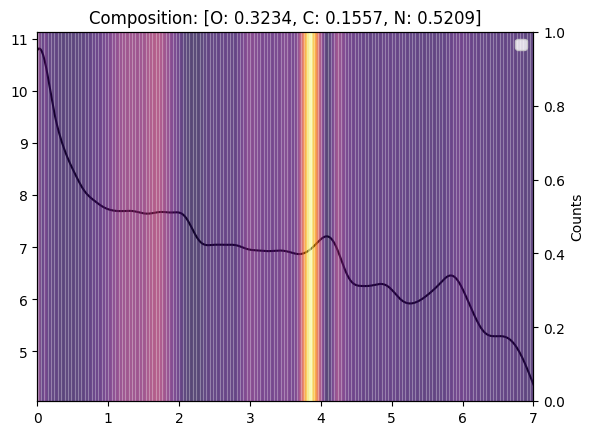

/tmp/ipykernel_180454/2357734430.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


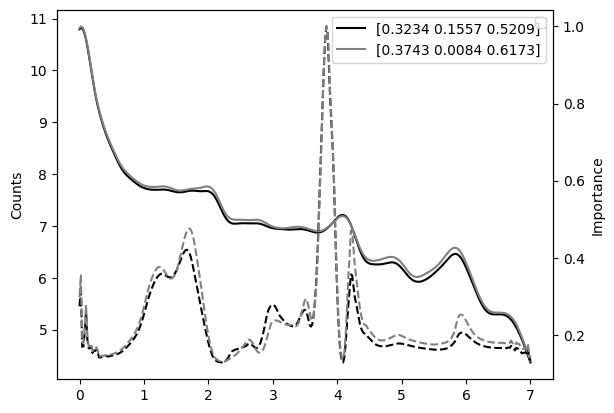

(1, 350, 1)
(1, 4, 350, 350)


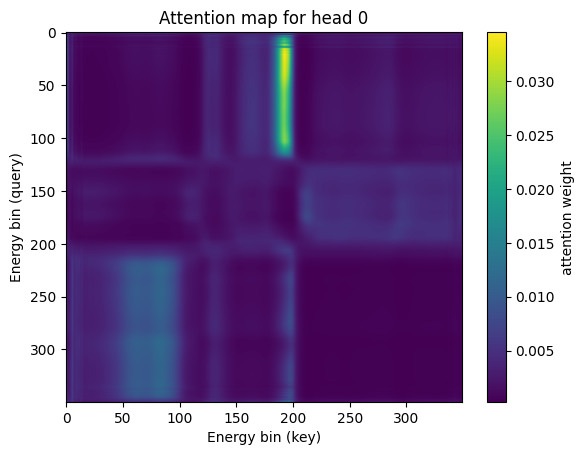

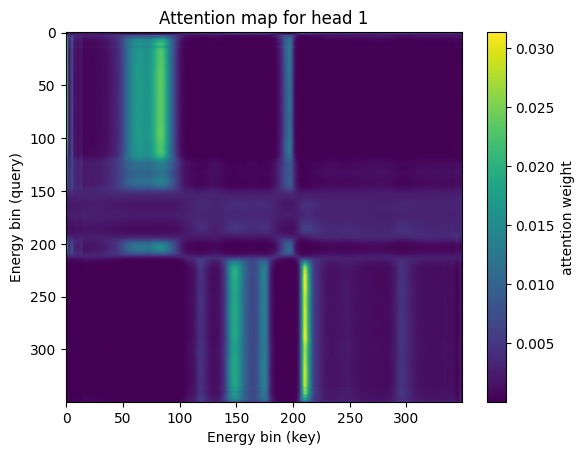

In [10]:
loaded_model_path = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/oxygen_loss_finetune_heavy/val_mae_0.0168_bs8__lr0.00003_epoch_802_val_mae_O_0.0042_val_mae_C_0.0225_val_mae_N_0.0237_val_median_ae_O_0.0029_val_median_ae_C_0.0204_val_median_ae_N_0.0184.keras"
#"spectroscopy/models/new_filters_finetune/val_mae_0.0107_bs8__lr0.00003_epoch_1250_val_mae_O_0.0094_val_mae_C_0.0132_val_mae_N_0.0096_val_median_ae_O_0.0081_val_median_ae_C_0.0131_val_median_ae_N_0.0063.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_filters/val_mae_0.0141_bs32__lr0.00003_epoch_1712_val_mae_O_0.0089_val_mae_C_0.0177_val_mae_N_0.0156_val_median_ae_O_0.0074_val_median_ae_C_0.0170_val_median_ae_N_0.0143_continue.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data_add_grad/val_mae_0.0244_bs32__lr0.00010_epoch_143_val_mae_O_0.0129_val_mae_C_0.0301_val_mae_N_0.0299_val_median_ae_O_0.0111_val_median_ae_C_0.0282_val_median_ae_N_0.0226.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data_attn_fixed_2/val_mae_0.0256_bs32__lr0.00010_epoch_121_val_mae_O_0.0144_val_mae_C_0.0319_val_mae_N_0.0302_val_median_ae_O_0.0110_val_median_ae_C_0.0290_val_median_ae_N_0.0267.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data_add_grad/val_mae_0.0244_bs32__lr0.00010_epoch_143_val_mae_O_0.0129_val_mae_C_0.0301_val_mae_N_0.0299_val_median_ae_O_0.0111_val_median_ae_C_0.0282_val_median_ae_N_0.0226.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data_attn_fixed_2/val_mae_0.0256_bs32__lr0.00010_epoch_121_val_mae_O_0.0144_val_mae_C_0.0319_val_mae_N_0.0302_val_median_ae_O_0.0110_val_median_ae_C_0.0290_val_median_ae_N_0.0267.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data_add_grad/val_mae_0.0244_bs32__lr0.00010_epoch_143_val_mae_O_0.0129_val_mae_C_0.0301_val_mae_N_0.0299_val_median_ae_O_0.0111_val_median_ae_C_0.0282_val_median_ae_N_0.0226.keras"
#"/spectroscopy/models/new_more_data_attn_fixed_norm/val_mae_0.0256_bs32__lr0.00010_epoch_121_val_mae_O_0.0144_val_mae_C_0.0319_val_mae_N_0.0302_val_median_ae_O_0.0110_val_median_ae_C_0.0290_val_median_ae_N_0.0267.keras"
#"/spectroscopy/models/new_more_data_attn_fixed_2/val_mae_0.0421_bs32__lr0.00010_epoch_82_val_mae_O_0.0167_val_mae_C_0.0564_val_mae_N_0.0534_val_median_ae_O_0.0146_val_median_ae_C_0.0519_val_median_ae_N_0.0504.keras"
#"spectroscopy/models/new_more_data_attn_fixed_2/val_mae_0.0256_bs32__lr0.00010_epoch_121_val_mae_O_0.0144_val_mae_C_0.0319_val_mae_N_0.0302_val_median_ae_O_0.0110_val_median_ae_C_0.0290_val_median_ae_N_0.0267.keras"
#"spectroscopy/models/new_more_data_attn_fixed/val_mae_0.0259_bs32__lr0.00010_epoch_127_val_mae_O_0.0128_val_mae_C_0.0316_val_mae_N_0.0332_val_median_ae_O_0.0105_val_median_ae_C_0.0300_val_median_ae_N_0.0329.keras"
dataset_to_test_X= X_val_2
dataset_to_test_y = y_val_2
loaded_model = load_model(loaded_model_path, compile = False)
loaded_att_layer = loaded_model.get_layer("attention_layer")
attn_scores = loaded_att_layer.output[1]
attention_model_loaded = Model(inputs=loaded_model.input, outputs=attn_scores)

print("dataset to test x shape", dataset_to_test_X.shape)
sample = dataset_to_test_X[9].reshape(1, 350, 1)
label = dataset_to_test_y[9]
prediction = loaded_model.predict(sample)#[:,:,0].reshape(1,350,1))
print("prediction:", prediction, "vs.real", label)

print("Oxygen error:", np.abs(prediction[0][0]- label[0]))

sample_2 = dataset_to_test_X[13].reshape(1, 350, 1)
print(sample.shape)

label_2 = dataset_to_test_y[13]

att = attention_model_loaded.predict(sample)#[:,:,0].reshape(1,350,1))
att_2 = attention_model_loaded.predict(sample_2)#[:,:,0].reshape(1,350,1))

# Average over all attention heads
att_avg = att.mean(axis = 1)[0] # 350 x 350
att_avg_2 = att_2.mean(axis = 1)[0] # 350 x 350

# Sum attention recieved by each bin --> shape(350,)
importance = att_avg.sum(axis=0)
importance = importance / importance.max()

importance_2 = att_avg_2.sum(axis=0)
importance_2 = importance_2 / importance_2.max()

energy = np.linspace(0, 7, 350)

fig, ax1 = plt.subplots()
plt.title("Composition: [O: " + str(label[0])+ ", C: "+ str(label[1]) + ", N: "+ str(label[2]) + "]")

ax1.plot(energy, sample[0,:,0], color = "black", label = "Spectrum")

ax2 = ax1.twinx()
#ax2.plot(energy, sample[0,:,1], color = "black", label = "Gradient")

for i in range(len(energy)-1):
    plt.axvspan(energy[i], energy[i+1], color=plt.cm.inferno(importance[i]), alpha = 0.35)

#plt.colorbar(plt.cm.ScalarMappable(cmap="inferno"), cax=)

#plt.colorbar(plt.cm.ScalarMappable(cmap="inferno"), label = "Attention weight (normalized)")
plt.xlabel("Energy [MeV]")
plt.ylabel("Counts")
plt.xlim(0,7)
plt.legend()
plt.show()

fig, ax1 = plt.subplots()
#plt.title("Composition: [O: " + str(label[0])+ ", C: "+ str(label[1]) + ", N: "+ str(label[2]) + "]")
ax1.plot(energy, sample[0,:,0], color = "black", label = str(label))
ax1.plot(energy, sample_2[0,:,0], color = "gray", label = str(label_2))

#ax1.plot(energy, sample[0,:,1], color = "black", label = str(label))
#ax1.plot(energy, sample_2[0,:,1], color = "gray", label = str(label_2))
plt.legend()
#ax1.axvline(x = 5.54, color = "green", alpha = 0.75, label = "5.54 MeV")
#ax1.axvline(x = 4.74, color = "orange", alpha = 0.75, label = "4.74 MeV")
#ax1.axvline(x = 3.8, color = "blue", alpha = 0.75, label = "3.8 MeV")
#plt.legend(loc= "upper left")
ax1.set_ylabel("Counts")

ax2 = ax1.twinx()
#ax2.set_ylim(0.5, 1.1)
ax2.plot(energy, importance, color = "black", linestyle = "--")
ax2.plot(energy, importance_2,color = "gray", linestyle = "--")
ax2.set_ylabel("Importance")
plt.legend()
plt.show()

print(sample.shape)
print(att.shape)


plt.title("Attention map for head 0")
plt.imshow(att[0,0,:,:], aspect = "auto")
plt.colorbar(label = "attention weight")
plt.xlabel("Energy bin (key)")
plt.ylabel("Energy bin (query)")
plt.show()

plt.title("Attention map for head 1")
plt.imshow(att[0,1,:,:], aspect = "auto")
plt.colorbar(label = "attention weight")
plt.xlabel("Energy bin (key)")
plt.ylabel("Energy bin (query)")
plt.show()

### FInd optimal LR

In [32]:
class LRFinder(tf.keras.callbacks.Callback):
    def __init__(self, min_lr, max_lr, steps):
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.total_steps = steps
        self.step = 0
        self.lrs = []
        self.losses = []

    def on_train_begin(self, logs=None):
        self._set_lr(self.min_lr)

    def _set_lr(self, lr):
        lr_attr = self.model.optimizer.learning_rate

        # Case 1: Variable (most common)
        if hasattr(lr_attr, "assign"):
            lr_attr.assign(lr)

        # Case 2: Python float
        else:
            self.model.optimizer.learning_rate = lr

    def on_batch_end(self, batch, logs=None):
        self.step += 1
        loss = logs["loss"]

        lr = self.min_lr * (self.max_lr / self.min_lr) ** (
            self.step / self.total_steps
        )

        self._set_lr(lr)

        self.lrs.append(lr)
        self.losses.append(loss)

        if math.isnan(loss) or loss > 10 * np.min(self.losses):
            self.model.stop_training = True

    def plot(self):
        plt.plot(self.lrs, self.losses)
        plt.xscale("log")
        plt.xlabel("Learning Rate")
        plt.ylabel("Loss")
        plt.title("LR Finder")
        plt.show()

In [38]:
bs = 8
steps_per_epoch = X_train.shape[0] // bs
model, attention_model = build_CNN(with_attention=True, num_channels=2, output_dim=6, auxillary_output = True) 

optimizer = Adam(learning_rate=1e-7)

model.compile(optimizer = optimizer, loss = {"composition": "kl_divergence","auxillary_output": "mae"}, loss_weights = {"composition": 1.0, "auxillary_output": 0.5}, metrics = {"composition" : ["mae", mae_O,mae_C,mae_N,mae_H,mae_Ca,mae_P], "auxillary_output": ["mae"]})

lr_finder = LRFinder(min_lr=1e-7, max_lr=1, steps = steps_per_epoch)

history = model.fit(X_train, y = {"composition": y_train[:,:6], "auxillary_output": y_train[:,6]}, epochs = 1,batch_size = bs,validation_data=(X_val,{"composition": y_val[:,:6], "auxillary_output": y_val[:,6]}),callbacks=lr_finder)



55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - auxillary_output_loss: 0.3642 - auxillary_output_mae: 0.3636 - composition_loss: 2.1658 - composition_mae: 0.1414 - composition_mae__ca: 0.1869 - composition_mae_c: 0.1637 - composition_mae_h: 0.1197 - composition_mae_n: 0.1118 - composition_mae_o: 0.1486 - composition_mae_p: 0.1244 - loss: 2.2644 - val_auxillary_output_loss: 0.5811 - val_auxillary_output_mae: 0.5811 - val_composition_loss: 11.7337 - val_composition_mae: 0.2759 - val_composition_mae__ca: 0.1703 - val_composition_mae_c: 0.8277 - val_composition_mae_h: 0.1582 - val_composition_mae_n: 0.1616 - val_composition_mae_o: 0.1693 - val_composition_mae_p: 0.1684 - val_loss: 12.0243


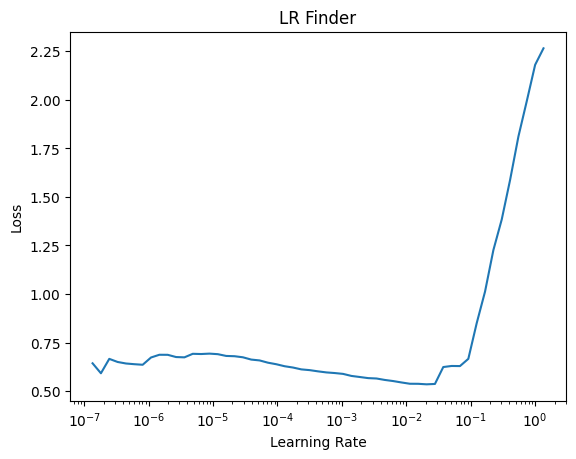

In [39]:
lr_finder.plot()

### Load pretrained model

In [ ]:
pretrained_model = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_filters/val_mae_0.0141_bs32__lr0.00003_epoch_1712_val_mae_O_0.0089_val_mae_C_0.0177_val_mae_N_0.0156_val_median_ae_O_0.0074_val_median_ae_C_0.0170_val_median_ae_N_0.0143_continue.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras" OBS DENNE BLE BRUKT FØR
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/synthetic/val_mae_0.0023_bs32__lr0.00001_epoch_199_val_mae_O_0.0021_val_mae_C_0.0029_val_mae_N_0.0020.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras"
model = load_model(pretrained_model, compile = False)

print("Number of layers in pretrained model:", len(model.layers))

#N = 16
#for layer in model.layers[:N]:
#    layer.trainable = False

# Hyperparameters for fine-tuning

num_epochs_ft = 2000
bs_ft = 8 # mindre bs her?
learning_rate_ft = 2.5e-5
loss_ft = make_weighted_loss(w_O = 0.25, w_C=3.0, w_N = 0.25) #(w_O = 3.0, w_C=0.25, w_N = 0.25) 
#"kl_divergence"

# Define model name 
model_name_finetune = f"bs{bs_ft}_lr_{learning_rate_ft:.4f}_loss_" + "carbon_specific_finetune_heavy"

log_dir = "logs/fit/carbon_specific/" + model_name_finetune + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callbacks = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq="epoch"
)


model.compile(optimizer = Adam(learning_rate=learning_rate_ft), loss = loss_ft, metrics = ["mae", mae_O,mae_C,mae_N, median_ae_O, median_ae_C, median_ae_N])

# Ta med early stopping, eller?

callbacks=[tensorboard_callbacks, ModelCheckpoint(
    f'models/carbon_loss_finetune_heavy/val_mae_{{val_mae:.4f}}_bs{bs_ft}__lr{learning_rate_ft:.5f}_epoch_{{epoch}}_val_mae_O_{{val_mae_o:.4f}}_val_mae_C_{{val_mae_c:.4f}}_val_mae_N_{{val_mae_n:.4f}}_val_median_ae_O_{{val_median_ae_o:.4f}}_val_median_ae_C_{{val_median_ae_c:.4f}}_val_median_ae_N_{{val_median_ae_n:.4f}}.keras',save_best_only=False)]

#X_train_real_syn = np.concatenate((X_train_2, X_array_syn), axis = 0)
#y_train_real_syn = np.concatenate((y_train_2, y_array_syn), axis = 0)

#print(X_train_real_syn.shape)
#print(y_train_real_syn.shape)
#history = model.fit([X_train,proton_counts_train], y_train, epochs = num_epochs,batch_size = bs,validation_data=([X_val, proton_counts_val],y_val),callbacks=callbacks)
history = model.fit(X_train_2, y_train_2, epochs = num_epochs_ft,batch_size = bs_ft,validation_data=(X_val_2,y_val_2),callbacks=callbacks)
#history = model.fit(X_train_real_syn, y_train_real_syn, epochs = num_epochs_ft,batch_size = bs_ft,validation_data=(X_val_2,y_val_2),callbacks=callbacks)





W0000 00:00:1776144761.077803  182982 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Number of layers in pretrained model: 27
Epoch 1/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - loss: 0.0723 - mae: 0.0685 - mae_c: 0.0591 - mae_n: 0.0585 - mae_o: 0.0878 - median_ae_c: 0.0570 - median_ae_n: 0.0606 - median_ae_o: 0.0869 - val_loss: 5.4851 - val_mae: 0.3724 - val_mae_c: 0.2894 - val_mae_n: 0.5578 - val_mae_o: 0.2699 - val_median_ae_c: 0.3522 - val_median_ae_n: 0.5348 - val_median_ae_o: 0.3054
Epoch 2/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - loss: 0.0338 - mae: 0.0449 - mae_c: 0.0421 - mae_n: 0.0482 - mae_o: 0.0444 - median_ae_c: 0.0396 - median_ae_n: 0.0464 - median_ae_o: 0.0409 - val_loss: 5.1927 - val_mae: 0.3672 - val_mae_c: 0.2894 - val_mae_n: 0.5485 - val_mae_o: 0.2637 - val_median_ae_c: 0.3522 - val_median_ae_n: 0.5220 - val_median_ae_o: 0.2996
Epoch 3/2000
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - loss: 0.0320 - mae: 0.0405 - mae_c: 0.0468 - mae_n: 0.0370 - mae_o: 0.0377 - median_ae_c: 0.0458 - median_ae_n: 0.0395 - median_ae_o: 0.0351 - val_loss: 5.0582

W0000 00:00:1776145282.624908  182982 op_kernel.cc:1858] OP_REQUIRES failed at summary_kernels.cc:150 : RESOURCE_EXHAUSTED: logs/fit/carbon_specific/bs8_lr_0.0000_loss_carbon_specific_finetune_heavy20260414-073241/train/events.out.tfevents.1776144761.ift-medfys-cl2.182982.0.v2; No space left on device
	Failed to flush 11 events to logs/fit/carbon_specific/bs8_lr_0.0000_loss_carbon_specific_finetune_heavy20260414-073241/train/events.out.tfevents.1776144761.ift-medfys-cl2.182982.0.v2
	Could not flush events file.
W0000 00:00:1776145282.625017  182982 local_rendezvous.cc:412] Local rendezvous is aborting with status: RESOURCE_EXHAUSTED: logs/fit/carbon_specific/bs8_lr_0.0000_loss_carbon_specific_finetune_heavy20260414-073241/train/events.out.tfevents.1776144761.ift-medfys-cl2.182982.0.v2; No space left on device
	Failed to flush 11 events to logs/fit/carbon_specific/bs8_lr_0.0000_loss_carbon_specific_finetune_heavy20260414-073241/train/events.out.tfevents.1776144761.ift-medfys-cl2.182982.

ResourceExhaustedError: {{function_node __wrapped__WriteSummary_device_/job:localhost/replica:0/task:0/device:CPU:0}} logs/fit/carbon_specific/bs8_lr_0.0000_loss_carbon_specific_finetune_heavy20260414-073241/train/events.out.tfevents.1776144761.ift-medfys-cl2.182982.0.v2; No space left on device
	Failed to flush 11 events to logs/fit/carbon_specific/bs8_lr_0.0000_loss_carbon_specific_finetune_heavy20260414-073241/train/events.out.tfevents.1776144761.ift-medfys-cl2.182982.0.v2
	Could not flush events file. [Op:WriteSummary]

### Training - scheme 2

In [ ]:
pretrained_model = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras"
model = load_model(pretrained_model, compile = False)

print("Number of layers in pretrained model:", len(model.layers))

#N = 16
#for layer in model.layers[:N]:
#    layer.trainable = False

# Hyperparameters for fine-tuning

num_epochs_ft = 300
bs_ft = 32 # mindre bs her?
learning_rate_ft = 1e-5
loss_ft = "kl_divergence"

# Define model name 
model_name_finetune = f"bs{bs_ft}_lr_{learning_rate_ft:.4f}_loss_" + loss_ft + "_synthetic_"

log_dir = "logs/fit/100mill/" + model_name_finetune + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callbacks = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=True,
    update_freq="epoch"
)


model.compile(optimizer = Adam(learning_rate=learning_rate_ft), loss = loss_ft, metrics = ["mae", mae_O,mae_C,mae_N])

# Ta med early stopping, eller?

callbacks=[tensorboard_callbacks, ModelCheckpoint(
    f'models/synthetic/val_mae_{{val_mae:.4f}}_bs{bs_ft}__lr{learning_rate_ft:.5f}_epoch_{{epoch}}_val_mae_O_{{val_mae_o:.4f}}_val_mae_C_{{val_mae_c:.4f}}_val_mae_N_{{val_mae_n:.4f}}.keras',save_best_only=False)]

#history = model.fit([X_train,proton_counts_train], y_train, epochs = num_epochs,batch_size = bs,validation_data=([X_val, proton_counts_val],y_val),callbacks=callbacks)
history = model.fit(X_train_syn, y_train_syn, epochs = num_epochs_ft,batch_size = bs_ft,validation_data=(X_val_syn,y_val_syn),callbacks=callbacks)



Number of layers in pretrained model: 27
Epoch 1/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 434ms/step - loss: 0.0102 - mae: 0.0346 - mae_c: 0.0244 - mae_n: 0.0388 - mae_o: 0.0408 - val_loss: 0.7574 - val_mae: 0.2001 - val_mae_c: 0.1033 - val_mae_n: 0.1917 - val_mae_o: 0.2951
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 411ms/step - loss: 0.0085 - mae: 0.0302 - mae_c: 0.0236 - mae_n: 0.0357 - mae_o: 0.0313 - val_loss: 0.6600 - val_mae: 0.1959 - val_mae_c: 0.1032 - val_mae_n: 0.1860 - val_mae_o: 0.2892
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 413ms/step - loss: 0.0071 - mae: 0.0279 - mae_c: 0.0208 - mae_n: 0.0331 - mae_o: 0.0297 - val_loss: 0.5240 - val_mae: 0.1734 - val_mae_c: 0.1028 - val_mae_n: 0.1527 - val_mae_o: 0.2555
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 408ms/step - loss: 0.0074 - mae: 0.0282 - mae_c: 0.0220 - mae_n: 0.0328 - mae_o: 0.0299 - val_loss: 0.4289 - val_mae: 0.1703 - val_mae_c: 0.1019 - val_mae_n: 0.1490 - val_mae_o: 0.2509
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 411m

KeyboardInterrupt: 

### Evaluate finetuned model

In [ ]:
best_finetuned_model ="/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/finetune_bs_fixed_synthetic/val_mae_0.0143_bs8__lr0.00001_epoch_293_val_mae_O_0.0132_val_mae_C_0.0152_val_mae_N_0.0145.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/finetune_bs_fixed/val_mae_0.0153_bs8__lr0.00001_epoch_201_val_mae_O_0.0139_val_mae_C_0.0167_val_mae_N_0.0153.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/finetune_synthetic/val_mae_0.0141_bs8__lr0.00001_epoch_280_val_mae_O_0.0111_val_mae_C_0.0164_val_mae_N_0.0128.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/finetune_1e-5_bs32/val_mae_0.0149_bs32__lr0.0000_epoch_228_val_mae_O_0.0118_val_mae_C_0.0169_val_mae_N_0.0159.keras"

best_model = load_model(best_finetuned_model, compile = False)

In [ ]:
prediction_array_X = X_test_2
prediction_array_y = y_test_2

print(prediction_array_X.shape, prediction_array_y.shape)


MAEs = []
labels = []
oksygen_true = []
carbon_true = []
nitrogen_true = []
oksygen_pred = []
carbon_pred = []
nitrogen_pred = []
for i in range(len(y_val_2)):
    y_true = prediction_array_y[i]
    y_pred = best_model.predict(prediction_array_X[i].reshape(1, 350, 1))#.reshape(1,350,2))
    MAE = np.mean(np.abs(y_true - y_pred), axis = 0)
    labels.append(y_true)
    MAEs.append(MAE)

    oksygen_true.append(y_true[0])
    carbon_true.append(y_true[1])
    nitrogen_true.append(y_true[2])

    oksygen_pred.append(y_pred[0][0])
    carbon_pred.append(y_pred[0][1])
    nitrogen_pred.append(y_pred[0][2])

print(len(labels))

(16, 350) (16, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
16


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
Mean absolute error (oxygen): 0.0154
Mean absolute error (carbon): 0.0128
Mean absolute error (nitrogen): 0.0139
------------------------------------------
Median absolute error (oxygen): 0.0144
Median absolute error (carbon): 0.0075
Median absolute error (nitrogen): 0.016
------------------------------------------


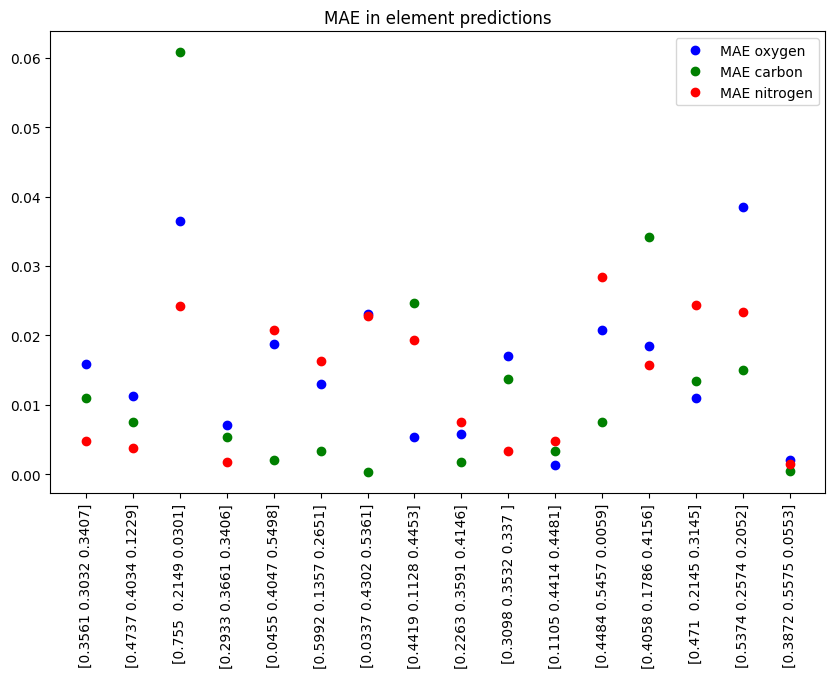

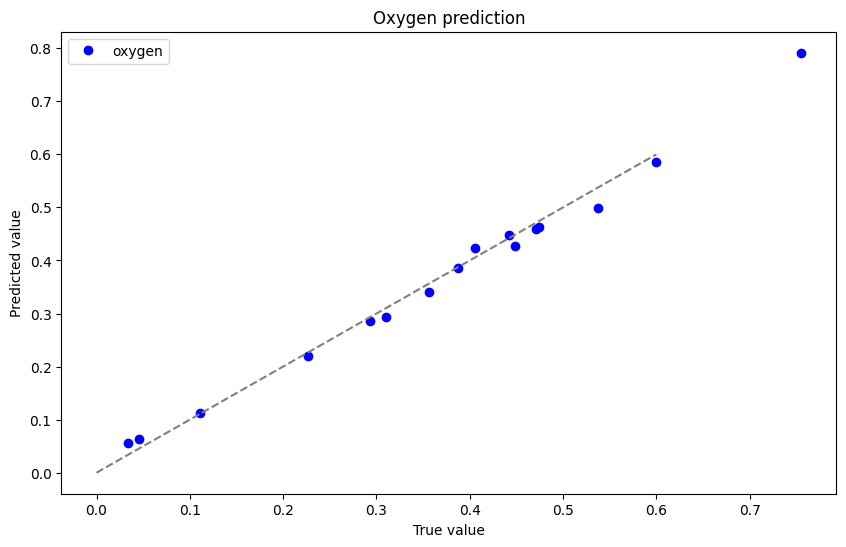

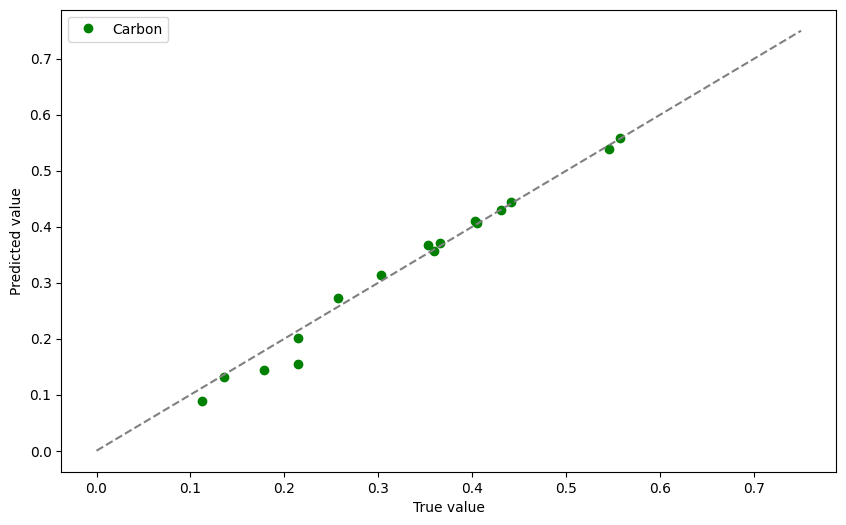

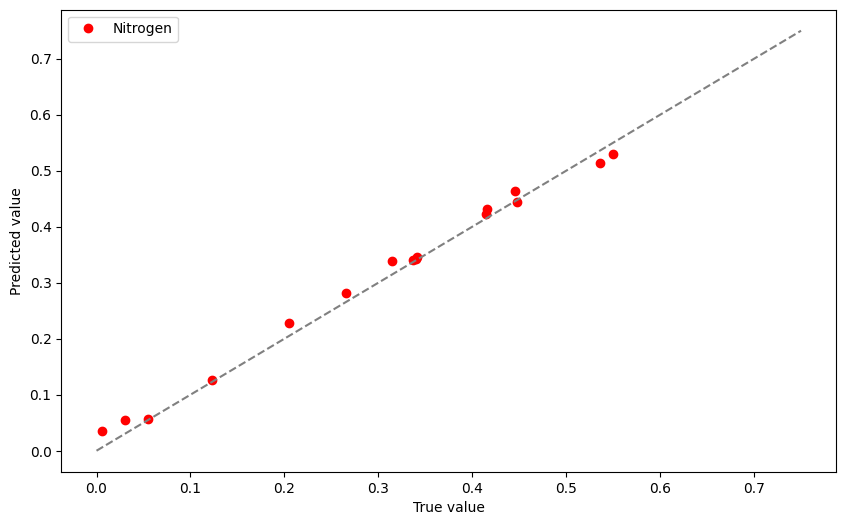

In [ ]:
Oxygen_errs = []
Carbon_errs = []
Nitrogen_errs = []
for i in range(len(MAEs)):
    Oxygen_errs.append(MAEs[i][0])
    Carbon_errs.append(MAEs[i][1])
    Nitrogen_errs.append(MAEs[i][2])

A = np.linspace(0,15,16)
print(A)

print("Mean absolute error (oxygen):", np.round(np.mean(Oxygen_errs), 4))
print("Mean absolute error (carbon):", np.round(np.mean(Carbon_errs), 4))
print("Mean absolute error (nitrogen):", np.round(np.mean(Nitrogen_errs), 4))
print("------------------------------------------")


print("Median absolute error (oxygen):", np.round(np.median(Oxygen_errs), 4))
print("Median absolute error (carbon):", np.round(np.median(Carbon_errs), 4))
print("Median absolute error (nitrogen):", np.round(np.median(Nitrogen_errs), 4))
print("------------------------------------------")

plt.figure(figsize=(10,6))
plt.title("MAE in element predictions")
plt.plot(Oxygen_errs, "bo", label = "MAE oxygen")
plt.plot(Carbon_errs, "go", label = "MAE carbon")
plt.plot(Nitrogen_errs, "ro",label = "MAE nitrogen")
plt.xticks(ticks = A , labels=labels, rotation = 90)
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.title("Oxygen prediction")
plt.plot(oksygen_true,oksygen_pred, "bo", label = "oxygen")
arr = np.linspace(0,0.6)
plt.plot(arr,arr, color = "gray", linestyle = "--")
plt.legend()
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(carbon_true,carbon_pred, "go", label = "Carbon")
arr = np.linspace(0,0.75)
plt.plot(arr,arr, color = "gray", linestyle = "--")
plt.legend()
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(nitrogen_true,nitrogen_pred, "ro", label = "Nitrogen")
arr = np.linspace(0,0.75)
plt.plot(arr,arr, color = "gray", linestyle = "--")
plt.legend()
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.show()
